In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap
import os
import networkx as nx
import igraph as ig
import leidenalg as la
import glob

# import geopandas


In [2]:
# choose basa or GG
database = 'GG' # 'basa' or 'GG'

def get_functional_categories(database):
    if database == 'basa':
        basa_groups = pd.read_csv('./data/basa/basa_groups.csv')
        # make a community_int column with integers from 0 to number of unique communities - 1
        basa_groups['Community_int'] = basa_groups['Community'].astype('category').cat.codes
        basa_partition = basa_groups.set_index('Taxa').to_dict()['Community_int']

        basa_community_index = basa_groups.set_index('Community').to_dict()['Community_int']
        basa_community_index_T = {v: k for k, v in basa_community_index.items()}

        return basa_partition, basa_community_index, basa_community_index_T

    if database == 'GG':
        GG_groups = pd.read_csv('./data/GG/gg_groups.csv')
        GG_groups['Community_int'] = GG_groups['Community'].astype('category').cat.codes
        GG_partition = GG_groups.set_index('Taxa').to_dict()['Community_int']
        GG_community_index = GG_groups.set_index('Community').to_dict()['Community_int']
        GG_community_index_T = {v: k for k, v in GG_community_index.items()}

        return GG_partition, GG_community_index, GG_community_index_T

    if database == 'moossee':
        moossee_groups = pd.read_csv('./data/moossee/groups_moossee.csv')
        moossee_groups['Community_int'] = moossee_groups['Community'].astype('category').cat.codes
        moossee_partition = moossee_groups.set_index('Taxa').to_dict()['Community_int']
        moossee_community_index = moossee_groups.set_index('Community').to_dict()['Community_int']
        moossee_community_index_T = {v: k for k, v in moossee_community_index.items()}

        return moossee_partition, moossee_community_index, moossee_community_index_T
    
    if database == 'Burgäschisee':
        Burgäschisee_groups = pd.read_csv('./data/Burgäschisee/groups_Burgäschisee.csv')
        Burgäschisee_groups['Community_int'] = Burgäschisee_groups['Community'].astype('category').cat.codes
        Burgäschisee_partition = Burgäschisee_groups.set_index('Taxa').to_dict()['Community_int']
        Burgäschisee_community_index = Burgäschisee_groups.set_index('Community').to_dict()['Community_int']
        Burgäschisee_community_index_T = {v: k for k, v in Burgäschisee_community_index.items()}

        return Burgäschisee_partition, Burgäschisee_community_index, Burgäschisee_community_index_T
    
if database == 'basa':
    results = 'results/basa'
    data_species = './GAM_species/basa/species_fit_140_0.01.pkl'
    windows = [(0, 40), (20, 60), (40, 80), (60, 100), (80, 120), (100, 140)]
    windows = [(0, 51), (52, 85), (85, 140)]
    windows = [(0, 51), (51, 85), (85, 140)]
    # windows = [(51, 85)]

if database == 'GG':
    results = 'results/GG'
    data_species = './GAM_species/GG/species_fit_300_0.01.pkl'
    windows = [(0, 100), (50, 150), (100, 200), (150, 250), (200, 300)]
    windows = [(150, 199), (200, 249)]
    windows = [(0, 56)]
    windows = [(0, 56), (57, 149), (150, 249), (250, 300)]
    windows = [(0, 57), (57, 150), (150, 250), (250, 300)]

if database == 'moossee':
    results = 'results/moossee'
    data_species = './GAM_species/moossee/species_fit_815_0.01.pkl'
    windows = [(0, 149)]
    windows = [(0, 149), (149, 380), (380, 644), (644, 815)]

if database == 'Burgäschisee':
    results = 'results/Burgäschisee'
    data_species = './GAM_species/Burgäschisee/species_fit_723_0.01.pkl'
    windows = [(0, 149)]
    windows = [(0, 180), (180, 465), (465, 723)]

species_index = pd.read_pickle(f'./GAM_species/{database}/species_index.pkl')
species_index_T = pd.Series(species_index)
species_index_T = pd.Series(species_index_T.index, index = species_index_T.values)
species_index_T = species_index_T.to_dict()

if database == 'basa':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'GG':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'moossee':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'Burgäschisee':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())

abundances = pd.read_pickle(data_species)

custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)

In [3]:
if database == 'basa':
    fire_colors = ["#9b031a","#FB990E","#e35412"]
    fire_markers = ['-o','-o','-o']
    fire_sizes = [1, 1, 1]
elif database == 'GG':
    fire_colors = ["#FB990E", '#9b031a', '#FB990E', '#9b031a'] # '#fb7923' this was the light one before
    fire_markers = ['-o','-o','-*','-*']
    fire_sizes = [1, 1, 2, 2]
elif database == 'moossee':
    fire_colors = ['orange', 'red', 'orange', 'red']
    fire_markers = ['-o','-o','-*','-*']
    fire_sizes = [1, 1, 2, 2]
elif database == 'Burgäschisee':
    fire_colors = ['red', 'pink', 'red']
    fire_markers = ['-o','-o','-*']
    fire_sizes = [1, 1, 2]

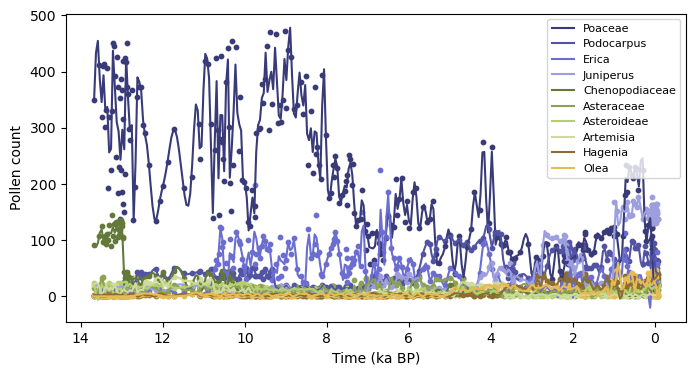

In [4]:
# plot the 10 species (all in the same axes) with highest total abundance over time
abundances_species = pd.DataFrame({k: v['y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})

prev_abundances_species = pd.DataFrame({k: v['prev_y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})
# sort by total abundance
abundances_species_sum = abundances_species.sum().sort_values(ascending=False)
top_10_species = abundances_species_sum.index[:10]

fig,ax = plt.subplots(figsize=(8, 4))

# get map
colors_sequence = plt.get_cmap('tab20b')(np.linspace(0, .5, len(top_10_species)))

for i,species in enumerate(top_10_species):
    ax.plot(-abundances[abundances.columns[1]]['x']/1000, abundances_species[species], color=colors_sequence[i], alpha=1, label=species)
    ax.scatter(-abundances[abundances.columns[1]]['prev_x']/1000, prev_abundances_species[species], color=colors_sequence[i], alpha=1, s=10)

# invert x axis
ax.invert_xaxis()
# ax.set_ylim(0,100)
ax.set_xlabel('Time (ka BP)')
ax.set_ylabel('Pollen count')
ax.legend(loc='upper right', fontsize=8)


In [5]:
import networkx as nx

def read_GC_network(causality_name):
    granger_causalities = []
    granger_causalities_p_values = []
    for idx,(start,end) in enumerate(windows):
        granger_causality = pd.read_pickle(f'{results}/{causality_name}/original_table_{start}-{end}.pkl')
        granger_causalities.append(granger_causality)

        granger_causality_p_values = pd.read_pickle(f'{results}/{causality_name}/bootstrapped_p_values_{start}-{end}.pkl')
        granger_causality_p_values[np.eye(granger_causality_p_values.shape[0], dtype=bool)] = np.nan
        granger_causalities_p_values.append(granger_causality_p_values)
    graphs = []

    for idx,(start,end) in enumerate(windows):
        
        # for the TE p_values (p_values_list) or the gc p_values (granger_causalities_p_values)
        # adjacency = p_values_list[idx]
        adjacency = granger_causalities_p_values[idx]
        # remove na from the numpy array adjacency
        adjacency = np.nan_to_num(adjacency, nan=1.0)
        # ONLY NON AQUATIC SPECIES
        species_list = list(species_index_T_non_aq.keys())

        # adjacency_non_aq = adjacency[np.ix_(species_list, species_list)]
        # cut_value = np.sort(adjacency_non_aq.flatten())[L]

        cut_value = 0.05

        adjacency_pvalued = (adjacency <= cut_value).astype(int)
        adjacency = granger_causalities[idx] * adjacency_pvalued


        graph = nx.from_numpy_array(adjacency, create_using=nx.DiGraph, edge_attr='weight')
        # remove all nodes that are not in the non_aq_species list
        graph.remove_nodes_from([node for node in graph.nodes() if species_index_T[node] not in non_aq_species])


        valid_species = 0
        invalid_species_list = []
        pollen_threshold = 0.5 # if the series have less than 3 values above 0.5, we consider it as not present, and we remove the links to and from that species
        
        for node in graph.copy().nodes():
            species_name = species_index_T[node]
            if (abundances[species_name]['y'][start : end] > pollen_threshold).sum() < 2.5:
                
                # set granger_causalities to 0 and granger_causalities_p_values to 1
                granger_causalities[idx][:, node] = 0
                granger_causalities[idx][node, :] = 0
                granger_causalities_p_values[idx][:, node] = 1
                granger_causalities_p_values[idx][node, :] = 1

                graph.remove_node(node)
                invalid_species_list.append(species_name)

            else:
                valid_species = valid_species + 1

        print("Invalid species in window ", start, end, ": ", len(invalid_species_list))
        print("Invalid species in window ", start, end, ": ", invalid_species_list)
        print("Valid species in window ", start, end, ": ", valid_species)
        
        graphs.append(graph)
        print(cut_value, graph.number_of_edges())
        # currently it's just set to cut a certain value (p=0.05), so it's simple

    return granger_causalities, granger_causalities_p_values, graphs

In [6]:
def read_bootstrap_GC_networks(causality_name):
    bootstrap_dir = f'{results}/{causality_name}'

    original_table = []
    bootstrapped_p_values = []

    for idx,(start,end) in enumerate(windows):
        try:
            original_table.append(pd.read_pickle(f'{bootstrap_dir}/original_table_{start}-{end}.pkl'))
        except:
            print(f'No original p-values for window {start}-{end}')
            raise Exception;

        bootstrapped_p_values.append(np.zeros(original_table[0].shape))

        # get every bootstrap table for this window -> pattern is for example /table_0-50_bs*.pkl
        pattern = f'{bootstrap_dir}/bootstrap_tables/table_{start}-{end}_bs*.pkl'
        bootstrap_files = glob.glob(pattern)
        nbootstraps = len(bootstrap_files)
        print('Number of bootstraps: ', nbootstraps)
        # for b in range(nbootstraps):

        prob_lower = np.zeros(original_table[idx].shape)
        prob_higher = np.zeros(original_table[idx].shape)

        for bootstrap_file in bootstrap_files:
            try:
                bootstrap_table = pd.read_pickle(bootstrap_file)
            except:
                print('Error reading bootstrap file: ', bootstrap_file)
            # now we compare original_table and one bootstrap_table. for every element in the matrix
            # if original_p_values[i,j] > 0, then we count the bootstrap_table[i,j] >= original_p_values[i,j]
            # if original_p_values[i,j] < 0, then we count the bootstrap_table[i,j] <= original_p_values[i,j]
            
            prob_lower += (bootstrap_table < original_table[idx]).astype(int)
            prob_higher += (bootstrap_table > original_table[idx]).astype(int)

            #_______________________________________________________________
            # bootstrapped_p_values[idx] += 2 * ((bootstrap_table >= original_table[idx]) * (original_table[idx] >= average_bootstrap_table) + (bootstrap_table <= original_table[idx]) * (original_table[idx] < average_bootstrap_table)).astype(int)
            bootstrapped_p_values[idx] += (np.abs(bootstrap_table) >= np.abs(original_table[idx])).astype(int)
            # THESE ASSUME A SYMMETRIC DISTRIBUTION (or short tailed), WHICH MAY NOT BE THE CASE
            #_______________________________________________________________

        bootstrapped_p_values[idx] = bootstrapped_p_values[idx] / nbootstraps
        # bootstrapped_p_values[idx] = 2 * np.minimum(prob_lower, prob_higher) / nbootstraps
        
        # write the p-values to a file
        pd.to_pickle(bootstrapped_p_values[idx], f'{bootstrap_dir}/bootstrapped_p_values_{start}-{end}.pkl')
    return original_table, bootstrapped_p_values

In [7]:
# SENSITIVITY

deviations = np.logspace(-2, np.log10(1), num=10)

# read table without deviations

causality_dir = 'sensitivity'
cond = f'cond1'


# read_bootstrap_GC_networks(f'{causality_dir}/{cond}')
granger_causalities, granger_causalities_p_values, graphs = read_GC_network(f'{causality_dir}/{cond}')

# pattern = f'{causality_dir}/{cond}/bootstrap_tables/table_{start}-{end}_bs*.pkl'
# bootstrap_files = glob.glob(pattern)
# nbootstraps = len(bootstrap_files)

granger_causalities_dev_j = []
graphs_dev_j = []
for dev_id, deviation in enumerate(deviations):
    granger_causalities_dev_j.append([])
    graphs_dev_j.append([])

    for j in range(0, 10):

        dev_j_dir = f'{causality_dir}/{cond}/deviation{dev_id}_j{j}'
        # read_bootstrap_GC_networks(dev_j_dir)
        gc_result, granger_causalities_p_values_count, graph_result = read_GC_network(dev_j_dir)

        granger_causalities_dev_j[dev_id].append(gc_result)
        graphs_dev_j[dev_id].append(graph_result)

Invalid species in window  0 57 :  40
Invalid species in window  0 57 :  ['Carduus', 'Polygonum', 'Tribulus', 'Hypericum', 'Myrsine', 'Rosa', 'Schefflera', 'Brucea', 'Iridaceae', 'Maytenus', 'Buxus', 'Psydrax', 'Celastraceae', 'Celtis', 'Ekebergia', 'Clematis', 'Allophylus', 'Commiphora', 'Cussonia', 'Dobera', 'Lannea', 'Macaranga', 'Jasminum', 'Rhus', 'Securinega', 'Teclea', 'Zanthoxylum', 'Euphorbia', 'Euphorbiacea', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Urticaceae', 'Ricinus']
Valid species in window  0 57 :  42
0.05 71
Invalid species in window  57 150 :  21
Invalid species in window  57 150 :  ['Carduus', 'Polygonum', 'Rosa', 'Brucea', 'Buxus', 'Psydrax', 'Celastraceae', 'Ekebergia', 'Allophylus', 'Cussonia', 'Macaranga', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Ricinus']
Valid species in window  57 150 :  61
0.05 121
Invalid spec

In [8]:
samples = 10

# number of links
links_dev = np.zeros((len(windows), deviations.size))
links_dev_std = np.zeros((len(windows), deviations.size))
links_dev_j = np.zeros((len(windows), deviations.size, samples))

# similarity to original network

similarities_dev = np.zeros((len(windows), deviations.size))
similarities_dev_std = np.zeros((len(windows), deviations.size))

for idx in range(len(windows)):
    for dev_id, deviation in enumerate(deviations):
        for j in range(0, samples):
            nedges = graphs_dev_j[dev_id][j][idx].number_of_edges()
            links_dev_j[idx][dev_id][j] = nedges
            links_dev[idx][dev_id] += nedges
            links_dev_std[idx][dev_id] += nedges * nedges

            edg1 = set(graphs[idx].edges)
            edg2 = set(graphs_dev_j[dev_id][j][idx].edges)
            similarity = len(edg1 & edg2) / len(edg1 | edg2)
            similarities_dev[idx][dev_id] += similarity
            similarities_dev_std[idx][dev_id] += similarity * similarity
            
        links_dev[idx][dev_id] /= samples
        similarities_dev[idx][dev_id] /= samples

        links_dev_std[idx][dev_id] = np.sqrt(links_dev_std[idx][dev_id]/samples -
                                             links_dev[idx][dev_id] * links_dev[idx][dev_id])
        similarities_dev_std[idx][dev_id] = np.sqrt(similarities_dev_std[idx][dev_id]/samples - 
                                                    similarities_dev[idx][dev_id] * similarities_dev[idx][dev_id])


/tmp/ipykernel_5247/3527085273.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
/tmp/ipykernel_5247/3527085273.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)


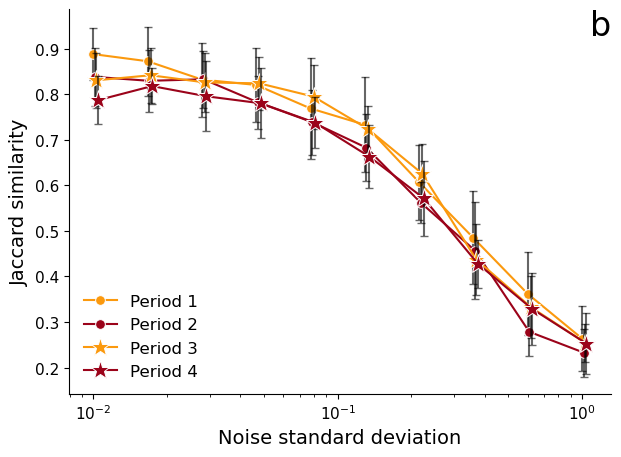

In [11]:
fig,ax = plt.subplots(figsize=(7,5))
for idx in range(len(windows)):
    ax.errorbar(deviations*(1+idx/70), similarities_dev[idx],
                yerr = similarities_dev_std[idx]*1.96, ecolor = 'black', fmt='.', markersize=0, alpha=0.6,
                capsize=3)
    ax.plot(deviations*(1+idx/70), similarities_dev[idx], fire_markers[idx], label = f'Period {idx+1}',
            color = fire_colors[idx], markersize=7*fire_sizes[idx], markeredgecolor='white', markeredgewidth=0.7)
    
ax.legend(fontsize=12, frameon=False, loc='lower left')

ax.set_xscale('log')
ax.set_xlabel('Noise standard deviation', size=14)
ax.set_ylabel('Jaccard similarity', size=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(1,1, 'b', fontsize=24,
        transform=ax.transAxes,
        va='top', horizontalalignment='right', clip_on=False)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

fig.savefig(f'plots-tests/sensitivity_similarity_{database}.pdf', dpi=300)


/tmp/ipykernel_5247/3379835778.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
/tmp/ipykernel_5247/3379835778.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)


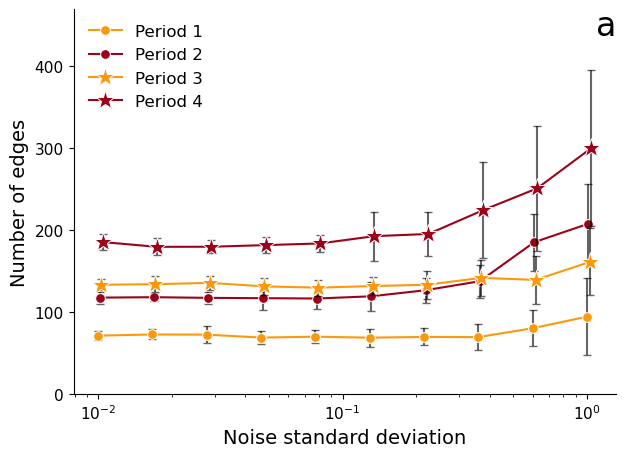

In [12]:
fig,ax = plt.subplots(figsize=(7,5))
for idx in range(len(windows)):
    ax.errorbar(deviations*(1+idx/70), links_dev[idx],
                yerr = links_dev_std[idx]*1.96, ecolor = 'black', fmt='.', markersize=0, alpha=0.6,
                capsize=3)
    ax.plot(deviations*(1+idx/70), links_dev[idx], fire_markers[idx], label = f'Period {idx+1}',
            color = fire_colors[idx], markersize=7*fire_sizes[idx], markeredgecolor='white', markeredgewidth=0.7)

ax.legend(fontsize=12, frameon=False, loc='upper left')
ax.set_xscale('log')
ax.set_ylim(0,470)
ax.set_xlabel('Noise standard deviation', size=14)
ax.set_ylabel('Number of edges', size=14)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(1,1, 'a', fontsize=24,
        transform=ax.transAxes,
        va='top', horizontalalignment='right', clip_on=False)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

fig.savefig(f'plots-tests/sensitivity_edges_{database}.pdf', dpi=300)

Window:  0 57
10 1
Galium Chenopodiaceae
Number of bootstraps:  4000
Coefficient =  -3.776776850365591
Mean =  0.09328505770795043
Std =  11.868766170372714
N extremos =  2284
p-value =  0.571


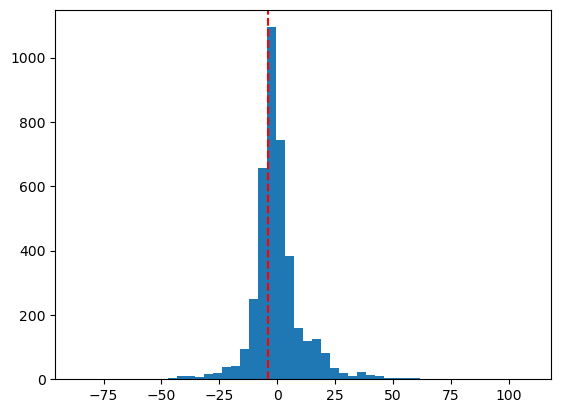

In [149]:
causality_name = 'bootstrap_conditional_GC_OLS/PAR_cond2_lag1'
bootstrap_dir = f'{results}/{causality_name}'

bootstrap_values_list = []

idx = 0
start,end = windows[idx]

# i = species_index_non_aq['Ulmus']
# j = species_index_non_aq['Poaceae']
i = 10
j = 1
print("Window: ", start, end)

print(i,j)
print(species_index_T_non_aq[i], species_index_T_non_aq[j])

try:
    original_table = pd.read_pickle(f'{bootstrap_dir}/original_table_{start}-{end}.pkl')
except:
    print(f'No original p-values for window {start}-{end}')
    raise Exception

bootstrapped_p_values = np.zeros(original_table.shape)

# get every bootstrap table for this window -> pattern is for example /table_0-50_bs*.pkl
pattern = f'{bootstrap_dir}/bootstrap_tables/table_{start}-{end}_bs*.pkl'
bootstrap_files = glob.glob(pattern)
nbootstraps = len(bootstrap_files)
print('Number of bootstraps: ', nbootstraps)
# for b in range(nbootstraps):
for bootstrap_file in bootstrap_files:
    try:
        bootstrap_table = pd.read_pickle(bootstrap_file)
    except:
        print('Error reading bootstrap file: ', bootstrap_file)
    bootstrapped_p_values += (np.abs(bootstrap_table) >= np.abs(original_table)).astype(int)
    bootstrap_values_list.append(bootstrap_table[i][j])
bootstrapped_p_values = bootstrapped_p_values / nbootstraps
bootstrap_values_list = np.array(bootstrap_values_list)
plt.hist(bootstrap_values_list.flatten(), bins=50)
plt.axvline(x=original_table[i][j], color='red', linestyle='--', label='Coefficient')

print("Coefficient = ", original_table[i][j])
print("Mean = ", np.mean(bootstrap_values_list.flatten()))
print("Std = ", np.std(bootstrap_values_list.flatten()))
# p-value
n_extremos = np.sum(np.abs(bootstrap_values_list.flatten()) >= np.abs(original_table[i][j]))
print("N extremos = ", n_extremos)
print("p-value = ",  (n_extremos) / (len(bootstrap_values_list.flatten())))

In [150]:
# set functional group as node attribute
for g in graphs:
    for node in g.nodes():
        species = species_index_T_non_aq[node]
        if species in custom_partition:
            g.nodes[node]['functional_group'] = custom_partition[species]
        else:
            g.nodes[node]['functional_group'] = -1

In [151]:
# calculate the number of positive and negative links within functional groups (just internal links) versus between functional groups
internal_links = []
external_links = []
total_links = []
for g in graphs:
    internal_pos_links = 0
    internal_neg_links = 0
    external_pos_links = 0
    external_neg_links = 0
    for u, v, data in g.edges(data=True):
        if g.nodes[u]['functional_group'] == g.nodes[v]['functional_group']:
            if data['weight'] > 0:
                internal_pos_links += 1
            elif data['weight'] < 0:
                internal_neg_links += 1
        else:
            if data['weight'] > 0:
                external_pos_links += 1
            elif data['weight'] < 0:
                external_neg_links += 1
    total_internal_links = internal_pos_links + internal_neg_links
    total_external_links = external_pos_links + external_neg_links

    percentage_negative_internal = internal_neg_links / total_internal_links if total_internal_links > 0 else 0
    percentage_negative_external = external_neg_links / total_external_links if total_external_links > 0 else 0
    percentage_total_links = (internal_neg_links + external_neg_links) / (total_internal_links + total_external_links)
    internal_links.append((percentage_negative_internal, total_internal_links))
    external_links.append((percentage_negative_external, total_external_links))
    total_links.append((percentage_total_links, total_internal_links + total_external_links))

print("Internal negatives: ", internal_links)
print("External negatives: ", external_links)
print("Total negatives: ", total_links)
print("\n")

Internal negatives:  [(0.47058823529411764, 17), (0.3, 20), (0.2857142857142857, 28), (0.21951219512195122, 41)]
External negatives:  [(0.5, 58), (0.4020618556701031, 97), (0.45871559633027525, 109), (0.30405405405405406, 148)]
Total negatives:  [(0.49333333333333335, 75), (0.38461538461538464, 117), (0.4233576642335766, 137), (0.2857142857142857, 189)]




In [152]:
# GIANT COMPONENT
for graph in graphs:
    print([len(c) for c in sorted(nx.connected_components(graph.to_undirected()), key=len, reverse=True)])

[41, 1, 1]
[61, 1]
[63, 1, 1, 1, 1]
[76, 1, 1, 1]


In [153]:

def sequential_custom_generator():
    colors_list = ['forestgreen', 'royalblue', 'crimson', 'grey', 'purple', 'orange']

    colors_list = ["#006ba6","#0281d3","#0496ff","#ffbc42","#f69248","#ec674e","#d81159","#8f2d56"] # reds and blues
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows

    # for 9 colors instead of 8
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d", "#0a662e"]

    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[random_indices[index] % len(colors_list)])
        index += 1

In [154]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *


def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) * 0.5
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L * 0.5
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, offset=0.0, node_radius_u=0.05, node_radius_v=0.05, arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

0.019290123456790122
(np.float64(-1.2266439189525538), np.float64(1.1595222980036288)) (np.float64(-1.2089403550029902), np.float64(1.1439387605143052))
0.019290123456790122
(np.float64(-1.2266439189525538), np.float64(1.1595222980036288)) (np.float64(-1.2019148074810726), np.float64(1.1436042106323092))
0.019290123456790122
(np.float64(-1.2266439189525538), np.float64(1.1595222980036288)) (np.float64(-1.222238406902473), np.float64(1.1639278100537096))


IndexError: index 3 is out of bounds for axis 0 with size 3

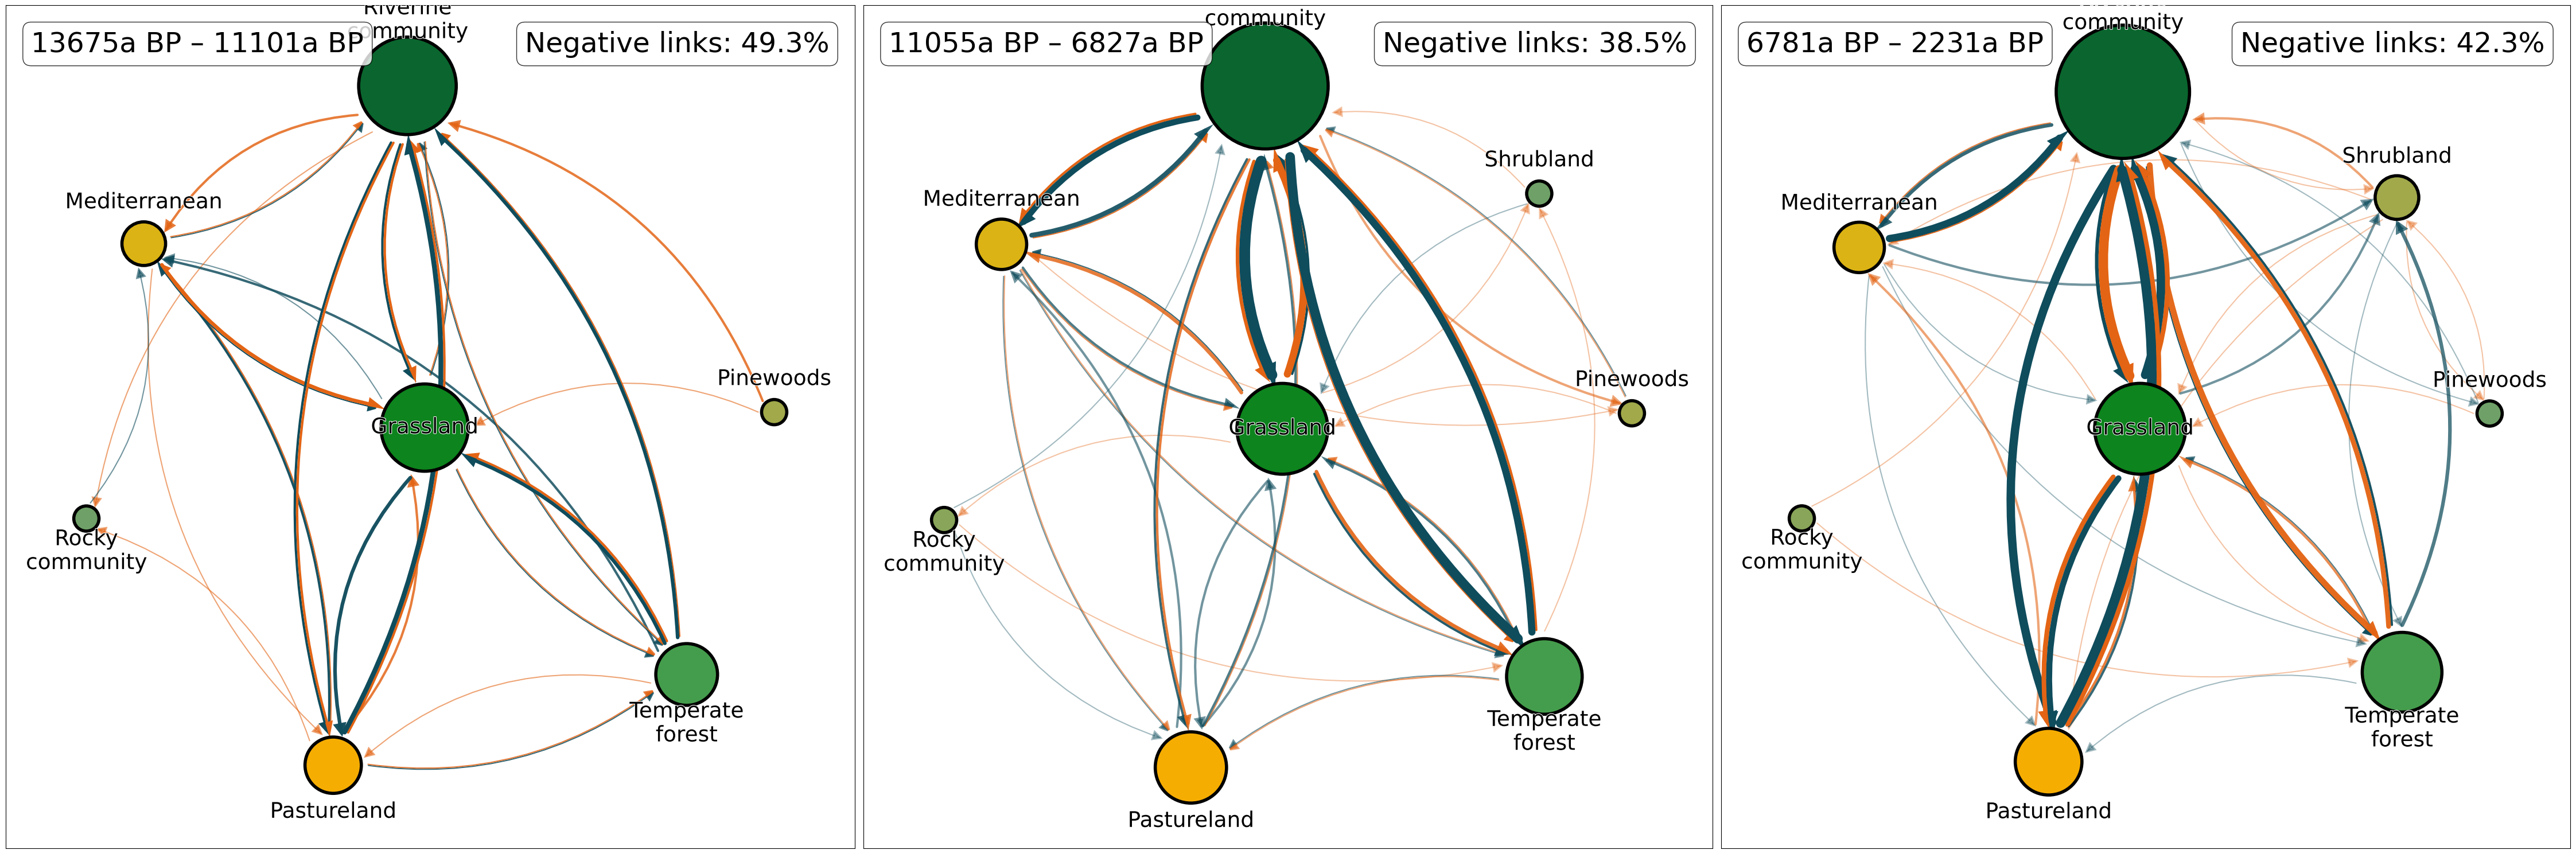

In [107]:
# BASA DE LA MORA
fig, axes = plt.subplots(1,3,figsize=(45, 15))

for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  7: 'Temperate\nforest',
                3: 'Pinewoods',
                6: 'Shrubland',
                4: 'Riverine\ncommunity',
                1: 'Mediterranean',
                2: 'Pastureland',
                0: 'Grassland',
                5: 'Rocky\ncommunity'}
    
    order = {   'Temperate\nforest'    :  1,
                'Pinewoods'  : 2,
                'Shrubland' : 3,
                'Riverine\ncommunity'   : 4,
                'Mediterranean' : 5,
                'Rocky\ncommunity'  : 6,
                'Pastureland' :   7
                 }
    
    N = len(G.nodes())
    initial_pos = {0: np.array([0.0, 0.0])}
    angle_step = 2 * np.pi / (N-1)
    for node, label in labels.items():
        # order nodes in a specific way
        # print(i, labels[node])
        if node != 0:
            angle = angle_step * (order[label]-2)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
    # pos[5] = np.array([-0.85,-0.5])
    # write pos to numpy file
    # np.save(f'plots-tests/pos_basa.npy', pos)
    pos = np.load(f'plots-tests/pos_basa.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/600000
    scale = 0.00085  # converts linewidth to offset in data space
    scale = 0.00112  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.06]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
# fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf', dpi=300)

0.019290123456790122
(np.float64(-1.267398980877502), np.float64(0.8231017388697399)) (np.float64(-1.1671700080259317), np.float64(1.2936747622869489))
0.019290123456790122
(np.float64(-1.2848483834177213), np.float64(1.189539192214351)) (np.float64(-1.1671700080259317), np.float64(1.2936747622869489))
0.019290123456790122
(np.float64(-1.2848483834177213), np.float64(1.189539192214351)) (np.float64(-1.1671700080259317), np.float64(1.2936747622869489))
0.019290123456790122
(np.float64(-1.4593424088199172), np.float64(1.0150451668121552)) (np.float64(-1.1739414106855277), np.float64(1.3004461649465449))


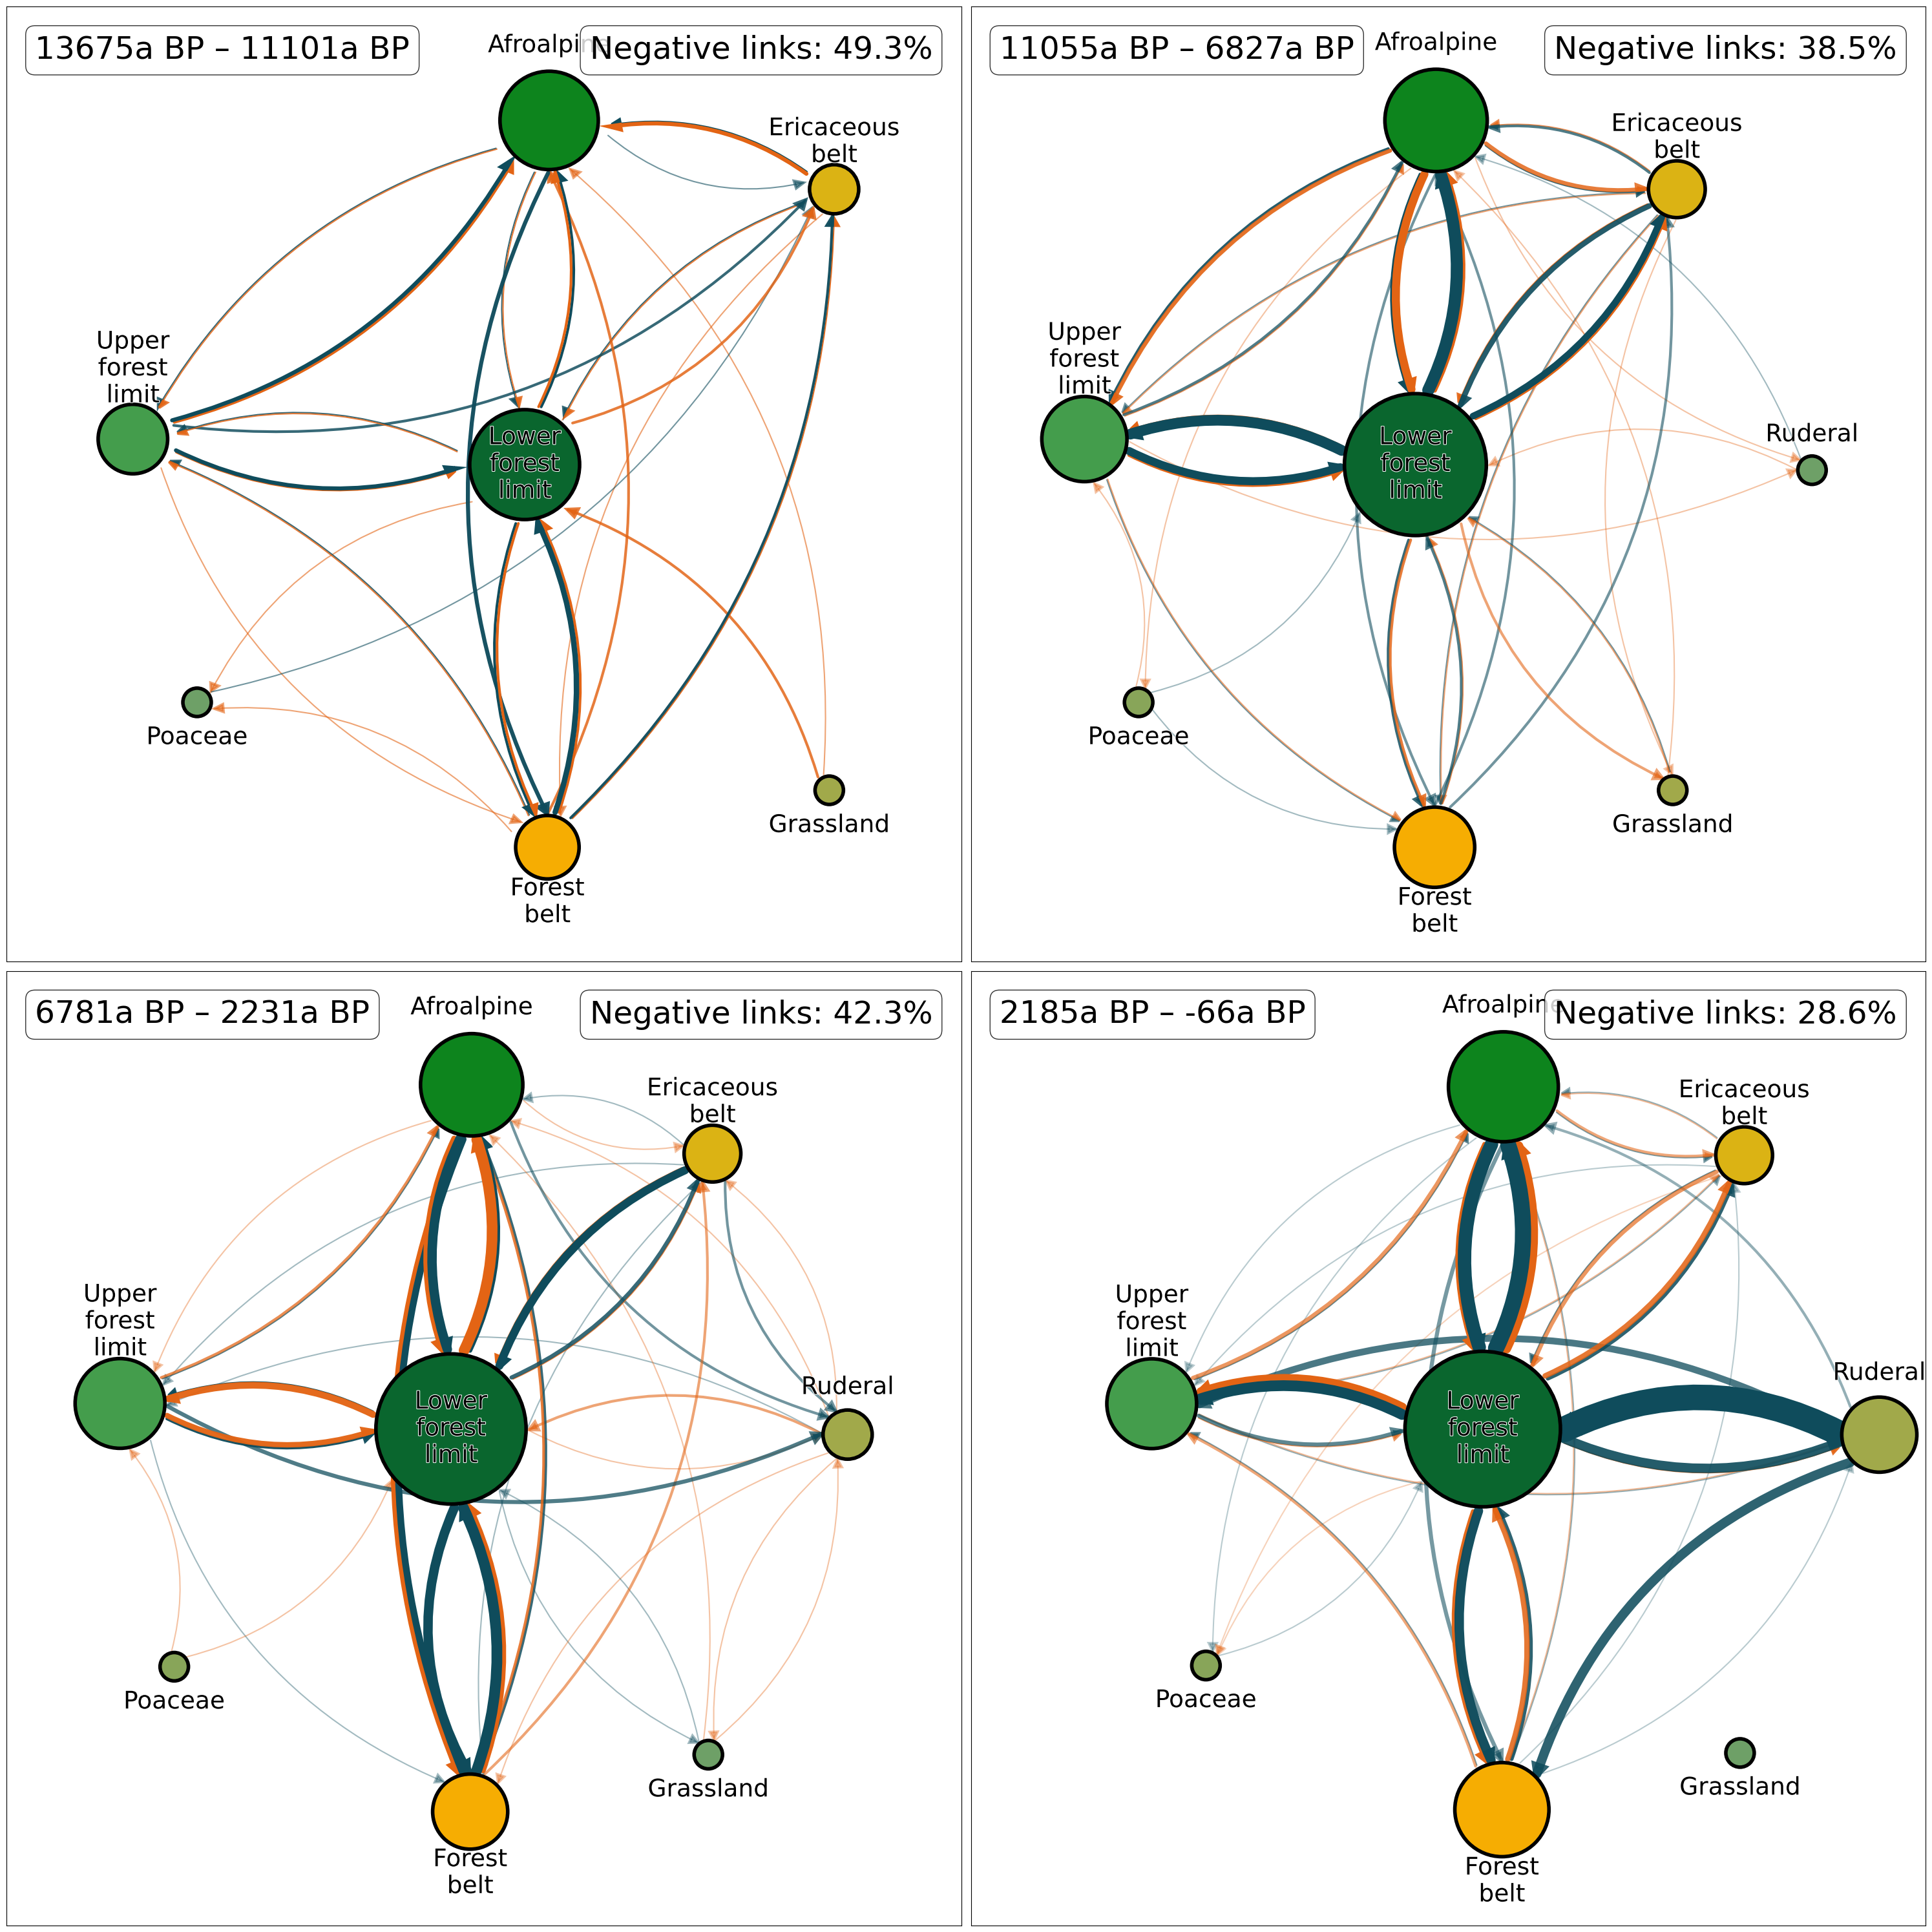

In [155]:
# GARBA GURACHA
fig, axes = plt.subplots(2,2,figsize=(30, 30))

for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes.flatten()[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle
    N = len(G.nodes())
    # angle_step = 2 * np.pi / (N - 1)
    angle_step = 2 * np.pi / (N)
    
    labels = {  0: 'Afroalpine',
                1: 'Ericaceous\nbelt',
                2: 'Forest\nbelt',
                3: 'Grassland',
                4: 'Lower\nforest\nlimit',
                5: 'Poaceae',
                6: 'Ruderal',
                7: 'Upper\nforest\nlimit'}

    initial_pos = {4: np.array([0.0, 0.0])}

    order = {'Grassland'    :   0,
                'Forest\nbelt' :   7,
                'Upper\nforest\nlimit' : 5,
                'Afroalpine'   : 3,
                'Ruderal'  : 1,
                'Ericaceous\nbelt' : 2,
                'Poaceae'  : 6
                }
    
    for node, label in labels.items():
        # order nodes in a specific way

        
        # print(i, labels[node])
        if node != 4:
            angle = angle_step * (order[label]-1)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    

    # pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=2)
    # pos[5] = np.array([-0.85,-0.5])
    # # write pos to numpy file
    # np.save(f'plots-tests/pos_GG.npy', pos)
    pos = np.load(f'plots-tests/pos_GG.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/700000
    scale = 0.00085  # converts linewidth to offset in data space
    scale = 0.00094  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    
    # set offset to label positions
                    
    label_pos = {n: pos[n] + np.array([0,0.0]) if labels[n] in ['Lower\nforest\nlimit'] else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.0013 - 0.05]) if labels[n] in ['Poaceae',
                                                                                                  'Forest\nbelt',
                                                                                                  'Grassland'] else
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.0013 + 0.08]) if labels[n] in ['Upper\nforest\nlimit'] else
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.0013 + 0.05])
                    for n in G.nodes()
                    }
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.20
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    ax.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
# fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf', dpi=300)



0.019290123456790122
(np.float64(-1.2328761787982216), np.float64(1.2301369608951536)) (np.float64(-1.23), np.float64(1.23))
0.019290123456790122
(np.float64(-1.23), np.float64(1.23)) (np.float64(-1.23), np.float64(1.23))
0.019290123456790122
(np.float64(-1.23), np.float64(1.23)) (np.float64(-1.2404169177052005), np.float64(1.2304960437002475))
0.019290123456790122
(np.float64(-1.235456480702724), np.float64(1.235456480702724)) (np.float64(-1.235456480702724), np.float64(1.235456480702724))


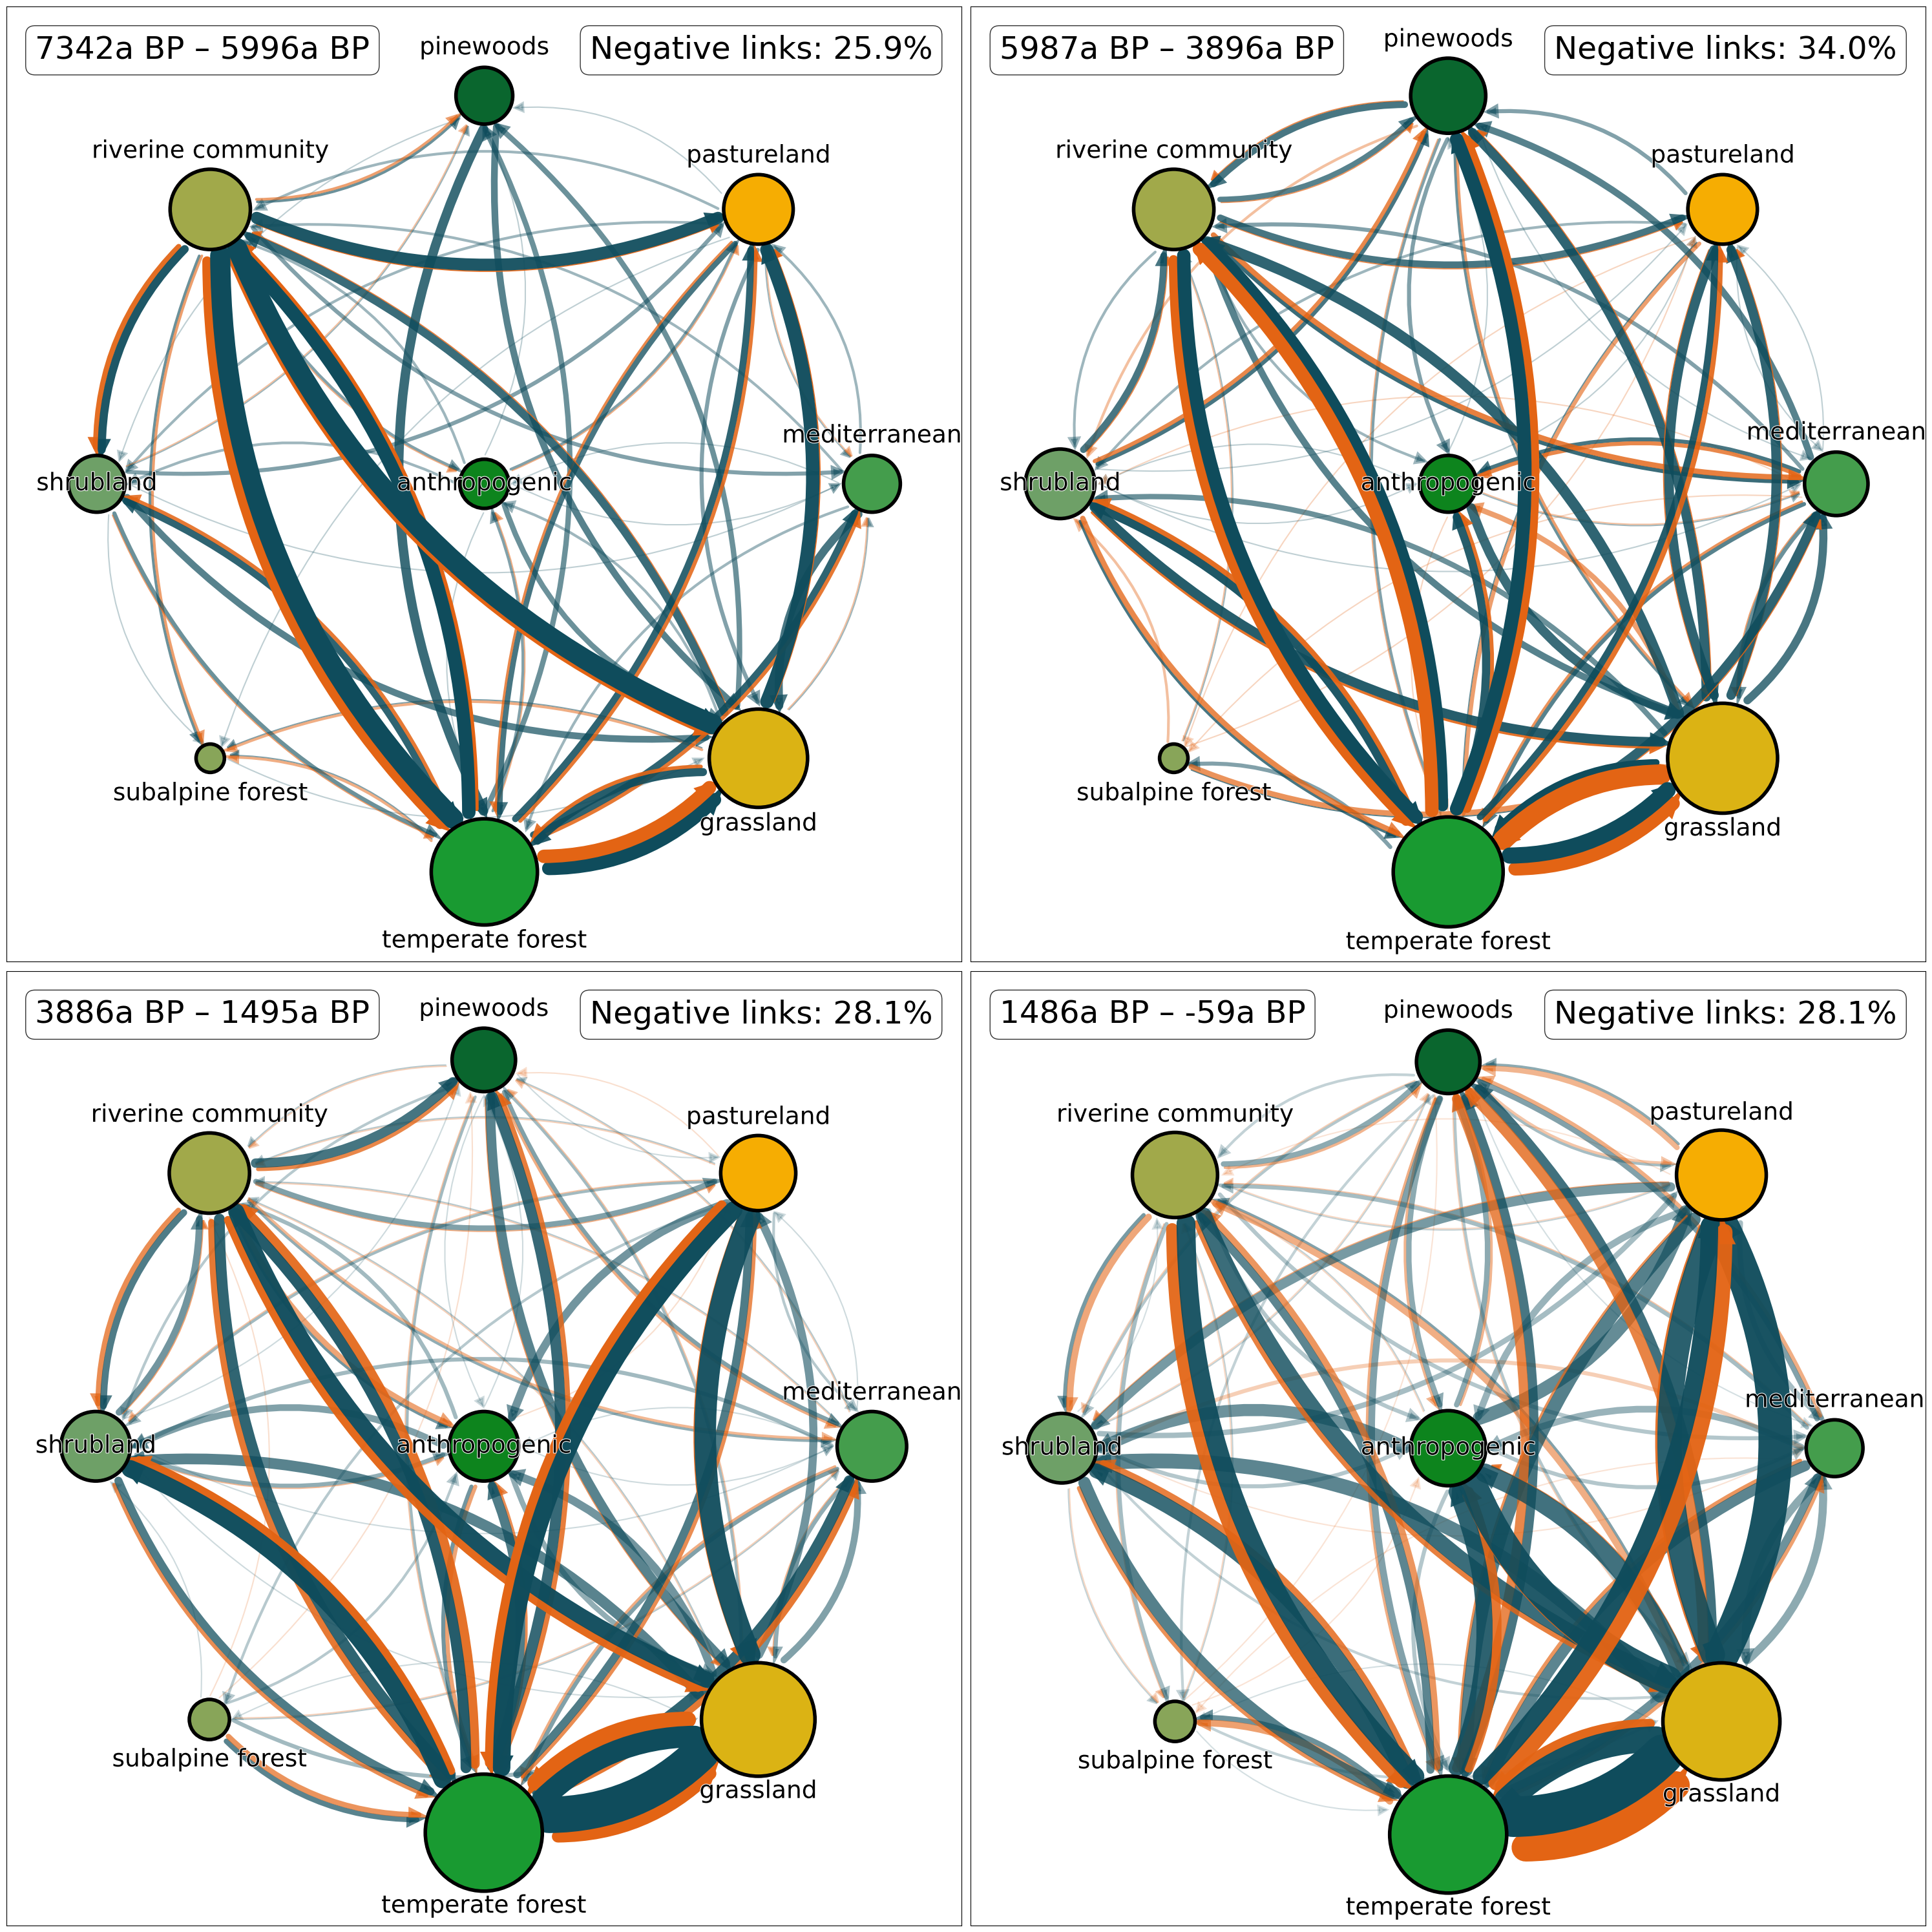

In [152]:
# MOOSSEE
fig, axes = plt.subplots(2,2,figsize=(30, 30))
axes = axes.flatten()
for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    # sort the dictionary by key
    fg_counts = dict(sorted(fg_counts.items(), key=lambda item: item[0]))
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  0: 'anthropogenic',
                1: 'grassland',
                2: 'mediterranean',
                3: 'pastureland',
                4: 'pinewoods',
                5: 'riverine community',
                6: 'shrubland',
                7: 'subalpine forest',
                8: 'temperate forest'}
    
    order = {'anthropogenic' : 0,
            'grassland' : 1,
            'mediterranean' : 2,
            'pastureland' : 3,
            'pinewoods' : 4,
            'riverine community' : 5,
            'shrubland' : 6,
            'subalpine forest' : 7,
            'temperate forest' : 8 }
    
    N = len(G.nodes())
    initial_pos = {0: np.array([0.0, 0.0])}
    angle_step = 2 * np.pi / (N-1)
    for node, label in labels.items():
        # order nodes in a specific way
        # print(i, labels[node])
        if node != 0:
            angle = angle_step * (order[label]-2)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
    pos = initial_pos
    # pos[5] = np.array([-0.85,-0.5])
    # write pos to numpy file
    np.save(f'plots-tests/pos_moossee.npy', pos)
    pos = np.load(f'plots-tests/pos_moossee.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/600000
    scale = 0.00112  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.06]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
# fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}_{lag}.pdf', dpi=300)

0.019290123456790122
(np.float64(-1.12601731129754), np.float64(1.2250484433951208)) (np.float64(-1.2119775866213964), np.float64(1.2028757930772151))
0.019290123456790122
(np.float64(-1.12601731129754), np.float64(1.2250484433951208)) (np.float64(-1.2323801327565467), np.float64(1.2038473428931744))
0.019290123456790122
(np.float64(-1.16859817177607), np.float64(1.267629303873651)) (np.float64(-1.4886358243569933), np.float64(0.9475916512927279))


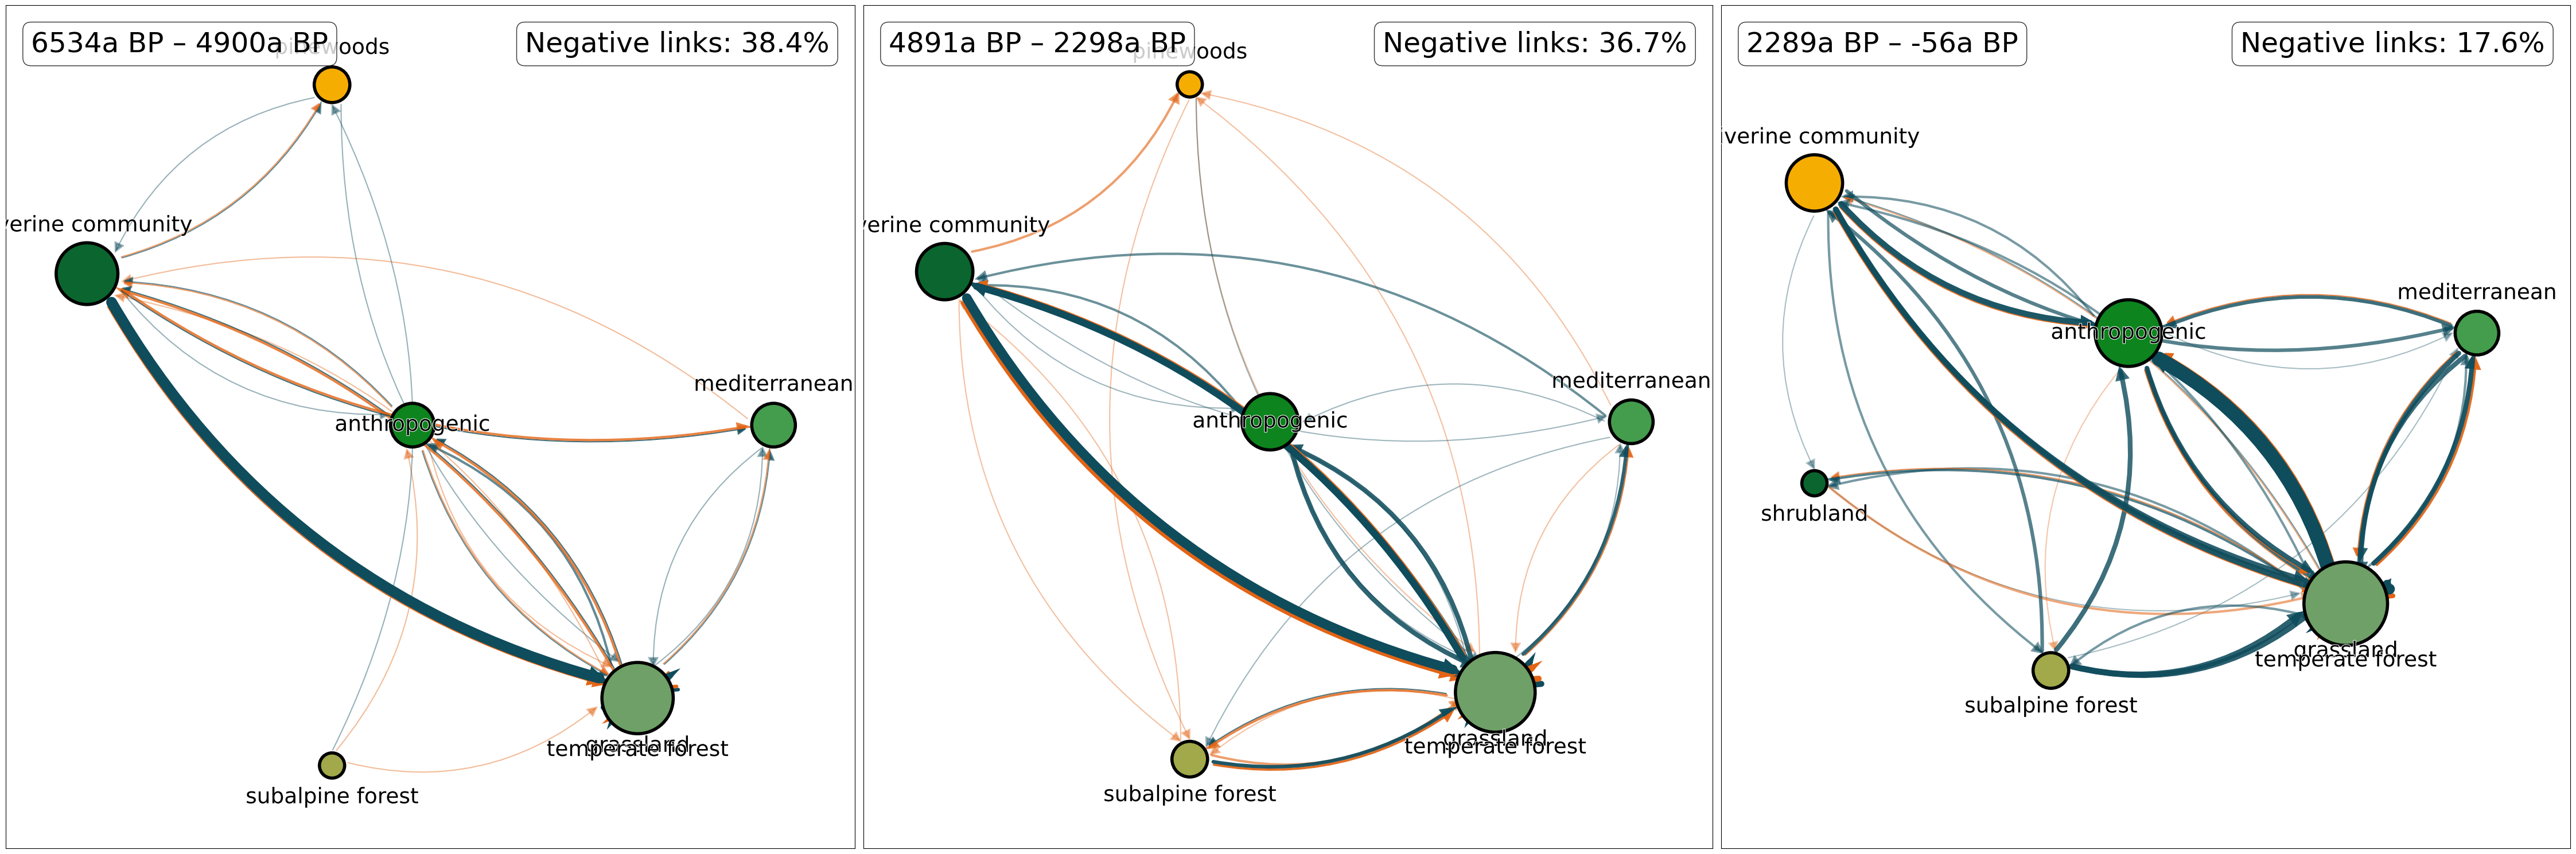

In [ ]:
# BURGASCHISEE
fig, axes = plt.subplots(1,3,figsize=(45, 15))
axes = axes.flatten()
for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    # sort the dictionary by key
    fg_counts = dict(sorted(fg_counts.items(), key=lambda item: item[0]))
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  0: 'anthropogenic',
                1: 'grassland',
                2: 'mediterranean',
                3: 'pastureland',
                4: 'pinewoods',
                5: 'riverine community',
                6: 'shrubland',
                7: 'subalpine forest',
                8: 'temperate forest'}
    
    order = {'anthropogenic' : 0,
            'grassland' : 1,
            'mediterranean' : 2,
            'pastureland' : 3,
            'pinewoods' : 4,
            'riverine community' : 5,
            'shrubland' : 6,
            'subalpine forest' : 7,
            'temperate forest' : 8 }
    
    N = len(G.nodes())
    initial_pos = {0: np.array([0.0, 0.0])}
    angle_step = 2 * np.pi / (N)
    for node, label in labels.items():
        # order nodes in a specific way
        # print(i, labels[node])
        if node != 0:
            angle = angle_step * (order[label]-2)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
    pos = initial_pos
    # pos[5] = np.array([-0.85,-0.5])
    # write pos to numpy file
    np.save(f'plots-tests/pos_moossee.npy', pos)
    pos = np.load(f'plots-tests/pos_moossee.npy', allow_pickle=True).item()



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/600000
    scale = 0.00112  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.06]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
    # add some margin to the xlim and ylim
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf', dpi=300)

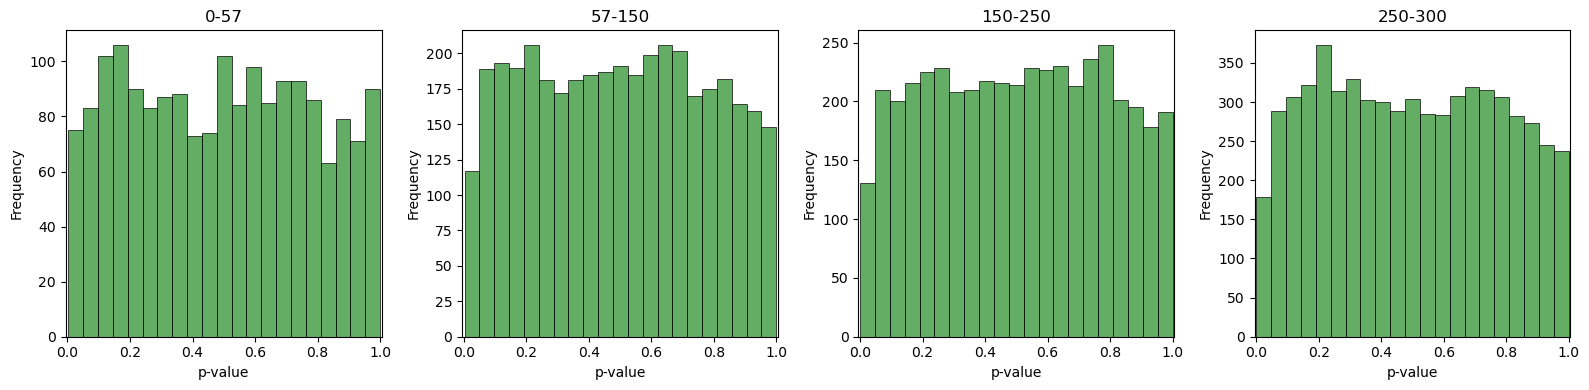

In [156]:
fig,axes = plt.subplots(1,len(windows),figsize=(4*len(windows), 4))
for idx in range(len(windows)):

    # every link that has a p-value of 1 in GC, put a p-value of 1 also in TE
    granger_causalities_p_values[idx][granger_causalities_p_values[idx] == 1.0] = np.nan
    # p_values_list[idx][granger_causalities_p_values[idx] == 1.0] = np.nan

    ax = axes.flatten()[idx]
    # ax.hist(p_values_list[idx].flatten(), bins = int(51), alpha=0.5, edgecolor='black', linewidth=0.25, color='blue', label='TE')
    granger_causality_pvalues = granger_causalities_p_values[idx].flatten()
    ax.hist(granger_causality_pvalues, bins = int(21), alpha=0.7, edgecolor='black', linewidth=0.7, color='forestgreen', label='GC')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Frequency')
    # ax.legend()
    (start, end) = windows[idx]
    ax.set_title(f'{start}-{end}')
    ax.set_xlim(-0.005,1.005)
fig.set_tight_layout(True)
# fig.savefig(f'./plots_notes/p_values_GG.png', dpi=300)

In [157]:
def get_p_values_df(granger_causalities_p_values, granger_causalities, idx):
    # find out which species have the lowest p value
    p_values = granger_causalities_p_values[idx] # a numpy matrix of the pairs of species and the p-value of their granger causality
    causality_values = granger_causalities[idx] # a numpy matrix of the pairs of species and the granger causality value
    # find the pair with the lowest p-value
    
    # create a dataframe with all the pairs of species and their p-values
    rows_pvalues = []
    for i in range(p_values.shape[0]):
        for j in range(p_values.shape[1]):
            if not np.isnan(p_values[i, j]):
                try:
                    row = {'species_1': species_index_T_non_aq[i], 'species_2': species_index_T_non_aq[j], 'p_value': p_values[i, j], 'causality_value': causality_values[i, j]}
                    rows_pvalues.append(row)
                except KeyError:
                    # species not in the non_aq_species list
                    pass
    p_values_df = pd.DataFrame(rows_pvalues)
    p_values_df = p_values_df.sort_values(by='p_value', ascending=True)
    return p_values_df

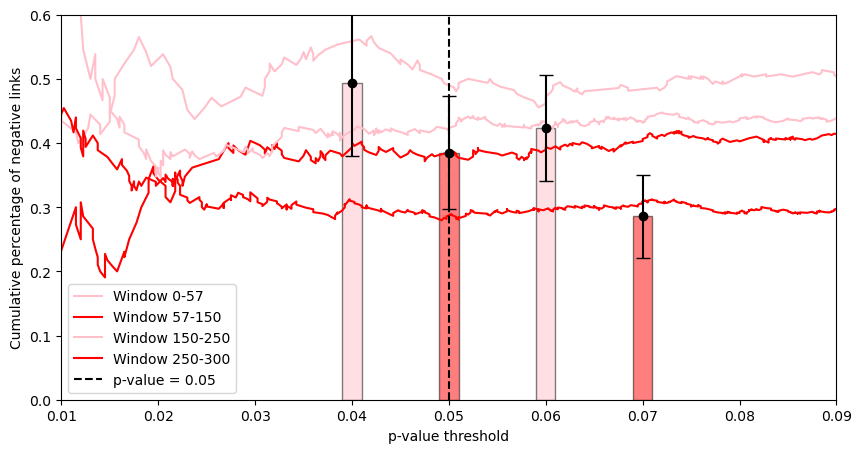

In [158]:

fig, ax = plt.subplots(figsize=(10, 5))
if database == 'basa':
    colors = ['red', 'pink', 'orange']
elif database == 'GG':
    colors = ['pink', 'red', 'pink', 'red']
elif database == 'moossee':
    colors = ['orange', 'red', 'orange', 'red']
elif database == 'Burgäschisee':
    colors = ['red', 'pink', 'red']


for idx in range(len(windows)):

    p_values_df = get_p_values_df(granger_causalities_p_values, granger_causalities, idx=idx)
    
    # make an array that is the 'causality_value' column of p_values_df in which
    # every value is the percentage of negative values up until that row
    negative_values = p_values_df['causality_value'].values < 0
    cumulative_negatives = np.cumsum(negative_values)
    total_counts = np.arange(1, len(p_values_df) + 1)
    p_values_df['negative_percentage'] = cumulative_negatives / total_counts
    plt.plot(p_values_df['p_value'],p_values_df['negative_percentage'], color=colors[idx], label=f'Window {windows[idx][0]}-{windows[idx][1]}')

# plot a vertical line on p-value = 0.05
ax.axvline(x=0.05, color='black', linestyle='--', label='p-value = 0.05')
ax.legend()
ax.set_xlim(0.01,0.09)
ax.set_ylim(0, 0.6)

ax.set_xlabel('p-value threshold')
ax.set_ylabel('Cumulative percentage of negative links')


# margin of error
def MOE(p, n, z=1.96):
    return z * np.sqrt((p * (1 - p)) / n)
for idx in range(len(windows)):
    p_values_df = get_p_values_df(granger_causalities_p_values, granger_causalities, idx=idx)
    negative_values = p_values_df['causality_value'].values < 0
    cumulative_negatives = np.cumsum(negative_values)
    total_counts = np.arange(1, len(p_values_df) + 1)
    p_values_df['negative_percentage'] = cumulative_negatives / total_counts

    # get the negative percentage and moe at p-value = 0.05
    p_value_threshold = 0.05
    df_threshold = p_values_df[p_values_df['p_value'] <= p_value_threshold]
    if len(df_threshold) > 0:
        p_at_threshold = df_threshold['negative_percentage'].values[-1]
        n_at_threshold = len(df_threshold)
        moe = MOE(p_at_threshold, n_at_threshold)
        # bar plot
        ax.bar(idx*0.01+0.04, p_at_threshold, color=colors[idx], capsize=6, alpha=0.5, width=0.002, align='center', edgecolor='black', linewidth=1)
        ax.errorbar(idx*0.01+0.04, p_at_threshold, yerr=moe, fmt='o', color='black', capsize=5)

In [159]:
# margin of error
def MOE(p, n, z=1.96):#1.96
    return z * np.sqrt((p * (1 - p)) / n)

# fig_negative_links, ax_negative_links = plt.subplots(figsize=(12, 6))

for idx in range(len(windows)):
    x_place = idx + 3
    p_values_df = get_p_values_df(granger_causalities_p_values, granger_causalities, idx=idx)
    negative_values = p_values_df['causality_value'].values < 0
    cumulative_negatives = np.cumsum(negative_values)
    total_counts = np.arange(1, len(p_values_df) + 1)
    p_values_df['negative_percentage'] = cumulative_negatives / total_counts

    # get the negative percentage and moe at p-value = 0.05
    p_value_threshold = 0.05
    df_threshold = p_values_df[p_values_df['p_value'] <= p_value_threshold]
    if len(df_threshold) > 0:
        p_at_threshold = df_threshold['negative_percentage'].values[-1]
        n_at_threshold = len(df_threshold)
        moe = MOE(p_at_threshold, n_at_threshold)
        # bar plot
        ax_negative_links.bar(x_place, p_at_threshold, color=colors[idx], capsize=6, alpha=0.8, width=0.2, align='center', edgecolor='black', linewidth=1)

        ax_negative_links.errorbar(x_place, p_at_threshold, yerr=moe, fmt='o', color='black', capsize=5)
fig_negative_links
# plt.xticks(range(len(windows)), [f'{w[0]}-{w[1]}' for w in windows])

NameError: name 'ax_negative_links' is not defined

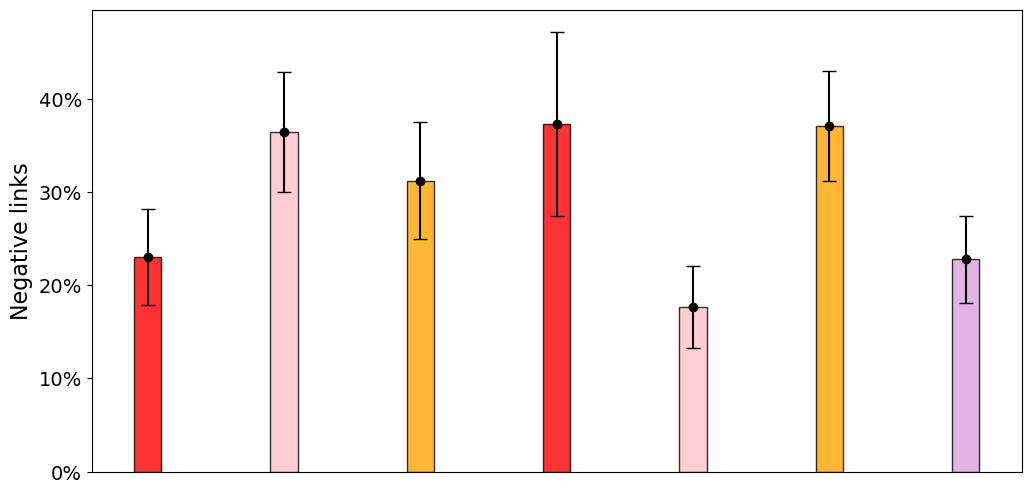

In [ ]:
ax_negative_links.set_xticks([])
ax_negative_links.set_ylabel('Negative links', fontsize=16)
# make the y a percentage so multiply by 100
# yticks = ax_negative_links.get_yticks()
# ax_negative_links.set_yticklabels([f'{int(y*100)}%' for y in yticks])
# increase size of ytick labels
ax_negative_links.tick_params(axis='y', labelsize=14)
fig_negative_links.savefig(f'./plots-tests/negative_links_percentage.png', dpi=300)

In [83]:
fig_negative_links.savefig(f'./plots-tests/negative_links_percentage.pdf', dpi=300)

In [110]:
p_values_df[p_values_df['causality_value'] > 100]

,species_1,species_2,p_value,causality_value
1031,Fagus,Quercus perennifolio,0.0353,5779.504576
1032,Fagus,Pistacia,0.0465,565.764551
1060,Fagus,Plantago,0.0574,864.010801
1065,Fagus,Lotus type,0.1008,965.708823
1055,Fagus,Cardueae,0.1143,408.367625
1040,Fagus,Ephedra distachya,0.1173,388.492961
1058,Fagus,Chenopodiaceae,0.1567,1077.693300
1072,Fagus,Urticaceae,0.1803,1920.632274
1023,Fagus,Ulmus,0.1941,785.691074
1084,Fagus,Ranunculaceae,0.3117,1258.311660


Fagus Quercus perennifolio
p-value =  0.0013
Quercus perennifolio Fagus
p-value =  0.6887


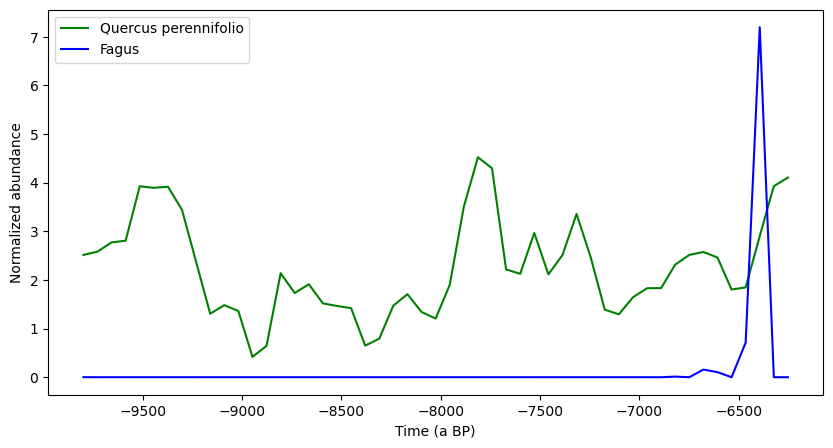

In [112]:
p_values_df = get_p_values_df(granger_causalities_p_values, granger_causalities, idx=0)

fig, ax = plt.subplots(figsize=(10, 5))
idx = 1
species1, species2 = p_values_df.loc[1031][['species_1', 'species_2']]
print(species1, species2)
print('p-value = ', p_values_df.iloc[idx]['p_value'])
print(species2, species1)
print('p-value = ', p_values_df[(p_values_df['species_2'] == species1) & (p_values_df['species_1'] == species2)].iloc[0]['p_value'])
# ax.plot(abundances[species1]['prev_x'][0:100], abundances[species1]['prev_y'][0:100], label=species1, color='blue')
# ax.plot(abundances[species2]['prev_x'][0:100], abundances[species2]['prev_y'][0:100], label=species2, color='red')

ab1 = (abundances[species1]['y'][0:51]) / np.std(abundances[species1]['y'][0:51])
ab2 = (abundances[species2]['y'][0:51]) / np.std(abundances[species2]['y'][0:51])
ax.plot(abundances[species2]['x'][0:51], ab2, label=species2, color='green')
ax.plot(abundances[species1]['x'][0:51], ab1, label=species1, color='blue')

# ax.plot(           abundances['Taxus']['y'][0:51], label='Taxus', lw=3)
# ax.plot(   abundances['Valerianaceae']['y'][0:51], label='Valerianaceae')
# ax.plot(abundances['Ephedra fragilis']['y'][0:51], label='Ephedra fragilis')
# print(p_values_df)

ax.set_xlabel('Time (a BP)')
ax.set_ylabel('Normalized abundance')

ax.legend()


## Degree distribution

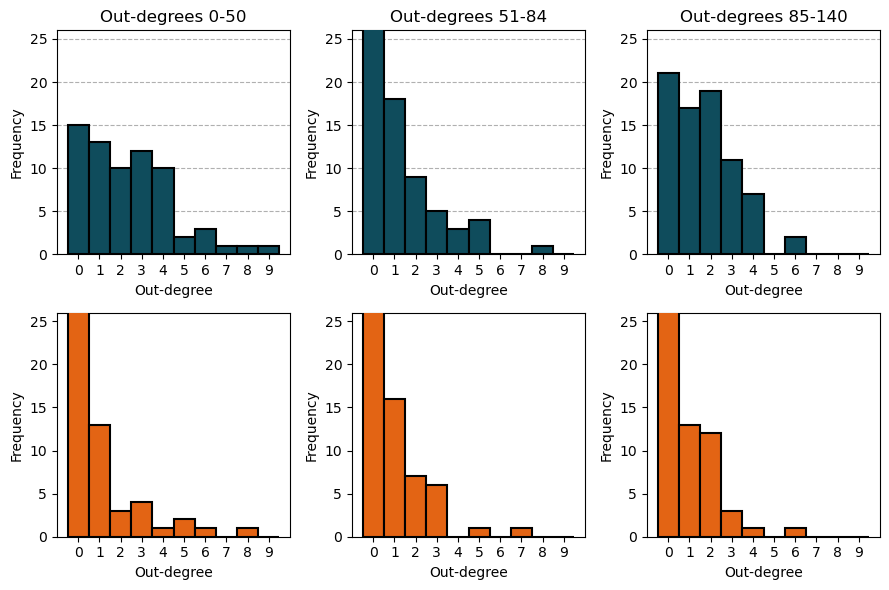

In [37]:
# calculate out-degree distributions

fig, axes = plt.subplots(2, len(windows), figsize=(3*len(windows), 6))
degree_distributions = []
for idx, graph in enumerate(graphs):
    # Only take into account nodes with abundance higher than 0

    # out_degree = np.array([graphs[idx].out_degree(n) for n in graphs[idx].nodes() if (abundances[species_index_T_non_aq[n]]['y'][windows[idx][0]:windows[idx][1]].sum() > 0)])
    
    out_degree_pos_dict = {}
    out_degree_neg_dict = {}
    for u in graphs[idx].nodes():
        out_degree_pos_dict[u] = 0
        out_degree_neg_dict[u] = 0

    for u, v, d in graphs[idx].edges(data=True):
        #calculate out degree by adding
        if d['weight'] > 0:
            out_degree_pos_dict[u] += 1
        if d['weight'] < 0:
            out_degree_neg_dict[u] += 1
    out_degree_pos = np.array(list(out_degree_pos_dict.values()))
    out_degree_neg = np.array(list(out_degree_neg_dict.values()))

    # degree_distributions.append(out_degree)
    # plot the degree distributions

    ax = axes.flatten()[idx]
    ax2 = axes.flatten()[idx+len(windows)]
    ax.grid(axis='y', zorder=0, linestyle='--', alpha=1)
    ax.hist(out_degree_pos, histtype='bar',
            bins=np.arange(-0.5, 10.5, 1),
            # bins=np.arange(-0.5, out_degree.max()+0.5, 1),
            density=False, zorder=3,
            edgecolor='black', linewidth=1.5, color = '#0F4C5C')
    ax2.hist(out_degree_neg, histtype='bar',
            bins=np.arange(-0.5, 10.5, 1),
            # bins=np.arange(-0.5, out_degree.max()+0.5, 1),
            density=False, zorder=3,
            edgecolor='black', linewidth=1.5, color = '#E36414')
    ax.set_xlabel('Out-degree')
    ax.set_ylabel('Frequency')
    (start, end) = windows[idx]
    ax.set_title(f'Out-degrees {start}-{end}')
    ax.set_ylim(0,26)
    ax.set_xticks(np.arange(0, 10, 1))
    ax.set_xticklabels(np.arange(0, 10, 1), rotation=0)
    ax2.set_xlabel('Out-degree')
    ax2.set_ylabel('Frequency')
    ax2.set_xticks(np.arange(0, 10, 1))
    ax2.set_xticklabels(np.arange(0, 10, 1), rotation=0)
    ax2.set_ylim(0,26)
fig.set_tight_layout(True)
# fig.savefig(f'./{results}/cgc_out_degree_distributions_firewindows.png', dpi=300)

Invalid species in window  0 149 :  25
Invalid species in window  0 149 :  ['Cannabis sativa', 'Juglans', 'Athyrium filix-femina', 'Sordaria-type', 'Hypericum', 'Cercophora-type', 'Sedum', 'Castanea', 'Scrophulariaceae', 'Centaurea', 'Viburnum', 'Humulus lupulus', 'Boraginaceae', 'Tussilago farfara', 'Hippophaë rhamnoides', 'Larix decidua', 'Platanus', 'Pteridophyta (trilete)', 'Ephedra fragilis', 'Lonicera', 'Helianthemum', 'Lotus type', 'Saxifragaceae', 'Ephedra distachya', 'Ribes']
Valid species in window  0 149 :  66
0.05 199
Invalid species in window  149 380 :  20
Invalid species in window  149 380 :  ['Cannabis sativa', 'Juglans', 'Sordaria-type', 'Cercophora-type', 'Polygonaceae', 'Castanea', 'Scrophulariaceae', 'Sanguisorba', 'Boraginaceae', 'Tussilago farfara', 'Hippophaë rhamnoides', 'Larix decidua', 'Platanus', 'Pteridophyta (trilete)', 'Primulaceae', 'Helianthemum', 'Lotus type', 'Quercus perennifolio', 'Ephedra distachya', 'Pistacia']
Valid species in window  149 380 :  7

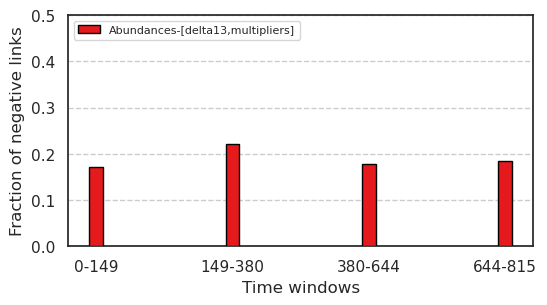

In [93]:
# make a bar plot of the percentage of negative links for each window, for different causality methods
import seaborn as sns
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(6, 3))
width = 0.1

# set color rotation palette
colors = sns.color_palette("Set1", 4)
plt.gca().set_prop_cycle(color=colors)
labels = ['Abundances-[delta13,multipliers]']
# labels = ['Abundances-[delta13]', 'PAR-[delta13]', 'Abundances-[delta13,multipliers]', 'PAR-[delta13,multipliers]']
for i, GC_method in enumerate(['bootstrap_conditional_GC/abundances_cond2']):
# for i, GC_method in enumerate(['conditional_GC/abundances_cond1', 'conditional_GC/PAR_cond1', 'conditional_GC/abundances_cond2', 'conditional_GC/PAR_cond2']):
    granger_causalities, granger_causalities_p_values, graphs = read_GC_network(f'{GC_method}')
    # Percentage of positive and negative links
    positive_links = []
    negative_links = []
    for j, graph in enumerate(graphs):
        positive_links.append(len([e for e in graph.edges(data=True) if e[2]['weight'] > 0]) / graph.number_of_edges())
        negative_links.append(len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges())

    ax.bar(np.arange(len(windows)) + i*width, negative_links, width, label=labels[i], zorder=3, edgecolor='black')
ax.set_xticks(np.arange(len(windows)))
ax.set_xticklabels([f'{start}-{end}' for (start, end) in windows])
ax.set_ylabel('Fraction of negative links')
ax.set_xlabel('Time windows')
ax.set_ylim(0, 0.50)
ax.grid(axis='y', zorder=0, linestyle='--', alpha=1)
ax.legend(loc='upper left', fontsize=8)

# fig.savefig(f'./plots_notes/negative_links_GG.png', dpi=300, bbox_inches='tight')

In [18]:
print(np.array(positive_links)*100)
print(np.array(negative_links)*100)

[76.6798419  59.47368421 67.82178218]
[23.3201581  40.52631579 32.17821782]


## Individual temporalities of nodes

91 287
1 - Temporality [0-56] -> [57-149]: 0.013   (mean random: 0.008, std: 0.006)
Edges kept: 5, Total edges: 373
287 245
1 - Temporality [57-149] -> [150-249]: 0.021   (mean random: 0.017, std: 0.010)
Edges kept: 11, Total edges: 521
245 308
1 - Temporality [150-249] -> [250-300]: 0.015   (mean random: 0.017, std: 0.009)
Edges kept: 8, Total edges: 545


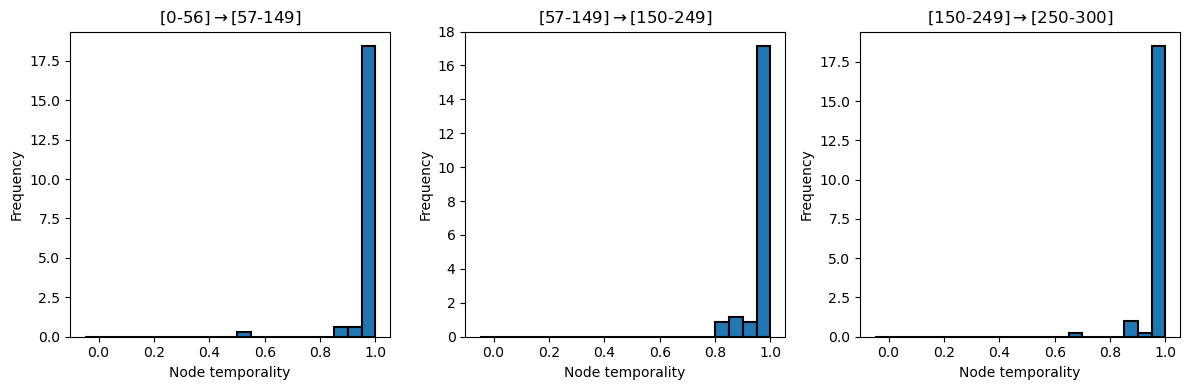

In [19]:
# individual temporalities of nodes
fig, axes = plt.subplots(1, len(windows)-1, figsize=(4*(len(windows)-1),4), layout='tight')

temporalities = pd.DataFrame(index = [species_index_T_non_aq[node] for node in graphs[idx].nodes()])

for i in range(0,len(graphs)-1):
    edg1 = set(graphs[i].edges)
    edg2 = set(graphs[i+1].edges)
    # edge temporality for each node: make a histogram of the number of edges that are present in both graphs for each node
    node_temporality = []
    for node in graphs[i].nodes():
        edg1_node = set(graphs[i].edges(node))
        edg2_node = set(graphs[i+1].edges(node))
        if len(edg1_node | edg2_node) != 0: 
            node_temporality.append(1 - len(edg1_node & edg2_node) / len(edg1_node | edg2_node))
        else:
            node_temporality.append(np.nan)

    # temporalities[i] = [node_temporality[i] for i, node in enumerate(graphs[idx].nodes())]
    
    # plot the histogram of node_temporality
    ax = axes.flatten()[i]
    ax.hist(node_temporality, bins=np.arange(-0.05, 1.05, 0.05), density=True,
            edgecolor='black', linewidth=1.5, histtype='bar', zorder=3)
    ax.set_xlabel('Node temporality')
    ax.set_ylabel('Frequency')
    ax.set_title(f'[{windows[i][0]}-{windows[i][1]}]' + r'$\rightarrow$' + f'[{windows[i+1][0]}-{windows[i+1][1]}]')

    #network temporality
    temporality = 1. - (1. - len(edg1 & edg2) / len(edg1 | edg2))
    edges_kept = len(edg1 & edg2)
    total_edges = len(edg1 | edg2)

    # compare with random graphs

    random_temporalities = np.zeros(100)  # Store temporality for 100 iterations
    n = graphs[i].number_of_nodes()
    l1 = graphs[i].number_of_edges()
    l2 = graphs[i+1].number_of_edges()
    print(l1, l2)
    for t in range(len(temporalities)):
        g1 = nx.gnm_random_graph(n, l1, directed=True)
        g2 = nx.gnm_random_graph(n, l2, directed=True)
        # calculate the temporality of the random graphs
        edg1 = set(g1.edges)
        edg2 = set(g2.edges)
        random_temporality = 1. - (1. - len(edg1 & edg2) / len(edg1 | edg2))
        random_temporalities[t] = random_temporality
        

    print(f'1 - Temporality [{windows[i][0]}-{windows[i][1]}] -> [{windows[i+1][0]}-{windows[i+1][1]}]: {temporality:.3f}' + 
          f'   (mean random: {random_temporalities.mean():.3f}, std: {random_temporalities.std():.3f})')
    print(f'Edges kept: {edges_kept}, Total edges: {total_edges}')

# fig.savefig(f'./{results}/node_temporality_firewinkdows.png', dpi=300, bbox_inches='tight')

## Distances between graphs (windows)

In [20]:
import networkx as nx
from collections import Counter
import hashlib

def weisfeiler_lehman_kernel(g1, g2, h=2):
    def initial_labeling(graph):
        return {node: str(graph.degree[node]) for node in graph.nodes()}
    
    def aggregate_labels(graph, labels):
        new_labels = {}
        for node in graph.nodes():
            neighbor_labels = sorted(labels[neighbor] for neighbor in graph.neighbors(node))
            long_label = labels[node] + "_" + "_".join(neighbor_labels)
            # Hash the label for uniqueness
            new_labels[node] = hashlib.md5(long_label.encode()).hexdigest()
        return new_labels

    def label_histogram(graph, h):
        labels = initial_labeling(graph)
        hist = Counter(labels.values())
        
        for i in range(h):
            labels = aggregate_labels(graph, labels)
            hist.update(labels.values())
        
        return hist

    hist1 = label_histogram(g1, h)
    hist2 = label_histogram(g2, h)

    # Compute kernel value as inner product (can also use other distances)
    kernel_value = sum(hist1[label] * hist2[label] for label in set(hist1) | set(hist2))
    return kernel_value

for idx in range(len(graphs)-1):
    similarity = weisfeiler_lehman_kernel(graphs[idx], graphs[idx+1], h=3)
    print(f"{windows[idx][0]}-{windows[idx][1]} to {windows[idx+1][0]}-{windows[idx+1][1]} similarity: {similarity:.3f}")

# similarity between similar random graphs
import random
def generate_random_graph(num_nodes, num_edges):
    G = nx.gnm_random_graph(num_nodes, num_edges, directed=True)
    return G

idx = 1
num_nodes = graphs[idx].number_of_nodes()
num_edges1 = graphs[idx].number_of_edges()
num_edges2 = graphs[idx+1].number_of_edges()
random_graphs1 = [generate_random_graph(num_nodes, num_edges1) for _ in range(10)]
random_graphs2 = [generate_random_graph(num_nodes, num_edges2) for _ in range(10)]
similarities = []

for idx in range(len(random_graphs1)):
    similarity = weisfeiler_lehman_kernel(random_graphs1[idx], random_graphs2[idx], h=3)
    similarities.append(similarity)
print(f"Average similarity between random graphs: {np.mean(similarities):.3f} ± {np.std(similarities):.3f}")

0-56 to 57-149 similarity: 2388.000
57-149 to 150-249 similarity: 1117.000
150-249 to 250-300 similarity: 604.000
Average similarity between random graphs: 779.600 ± 41.738
